# Roomly Historical Reservation Demand Analysis

This notebook analyses the historical Kaggle reservation dataset to produce verified demand metrics for the Roomly analytics dashboard.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Locate the project root regardless of the notebook working directory
project_root = Path.cwd()

if project_root.name == "analytics":
    project_root = project_root.parent

data_path = project_root / "data" / "reservations_cleaned_newversion.csv"

# Load room IDs as text and parse timestamps
df = pd.read_csv(
    data_path,
    dtype={"room_id": "string"},
    parse_dates=["start_time", "end_time"]
)

print("Dataset loaded from:", data_path)
print("Number of reservation records:", len(df))
print("Number of unique room identifiers:", df["room_id"].nunique())

display(df.head())

Dataset loaded from: C:\Users\yuche\Documents\GitHub\INF2006_ClassroomBooking\data\reservations_cleaned_newversion.csv
Number of reservation records: 51319
Number of unique room identifiers: 46


,start_time,end_time,duration_minutes,room_id,reservation_date,weekday,start_hour,month,is_weekend
0,2024-01-06 14:30:00,2024-01-06 18:00:00,210,109,2024-01-06,Saturday,14,1,True
1,2024-01-06 14:27:45,2024-01-06 16:27:45,120,033,2024-01-06,Saturday,14,1,True
2,2024-01-06 15:22:29,2024-01-06 16:22:29,60,326,2024-01-06,Saturday,15,1,True
3,2024-01-06 15:37:48,2024-01-06 17:37:48,120,107,2024-01-06,Saturday,15,1,True
4,2024-01-06 15:54:41,2024-01-06 17:54:41,120,032,2024-01-06,Saturday,15,1,True


## 1. Dataset Validation

The following checks confirm that the cleaned historical dataset has the expected number of records and rooms, valid timestamps, no missing values, no duplicate rows, and consistent reservation durations.

In [2]:
# Recalculate duration directly from the timestamps
calculated_duration = (
    df["end_time"] - df["start_time"]
).dt.total_seconds() / 60

duration_difference = calculated_duration - df["duration_minutes"]

rounded_duration_rows = int(
    (duration_difference.abs() > 0.001).sum()
)

duration_errors = int(
    (duration_difference.abs() > 0.5).sum()
)

validation_results = pd.DataFrame({
    "check": [
        "Reservation records",
        "Unique room identifiers",
        "Missing values",
        "Duplicate rows",
        "Duration errors beyond rounding tolerance"
    ],
    "actual_result": [
        len(df),
        df["room_id"].nunique(),
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
        duration_errors
    ],
    "expected_result": [
        51319,
        46,
        0,
        0,
        0
    ]
})

validation_results["status"] = (
    validation_results["actual_result"]
    == validation_results["expected_result"]
).map({True: "PASS", False: "FAIL"})

display(validation_results)

assert len(df) == 51319
assert df["room_id"].nunique() == 46
assert df.isna().sum().sum() == 0
assert df.duplicated().sum() == 0
assert duration_errors == 0

print("All dataset validation tests passed.")
print(
    f"{rounded_duration_rows} records contain harmless "
    "timestamp-to-minute rounding differences of no more than 0.5 minutes."
)

,check,actual_result,expected_result,status
0,Reservation records,51319,51319,PASS
1,Unique room identifiers,46,46,PASS
2,Missing values,0,0,PASS
3,Duplicate rows,0,0,PASS
4,Duration errors beyond rounding tolerance,0,0,PASS


All dataset validation tests passed.
2519 records contain harmless timestamp-to-minute rounding differences of no more than 0.5 minutes.


**Duration validation note:**  
The `duration_minutes` field stores whole minutes, while the start and end timestamps include seconds. A total of 2,519 records therefore differ slightly from the timestamp-derived duration. The maximum difference is 0.5 minutes, which is consistent with rounding to the nearest whole minute. No records were removed.

In [3]:
# Investigate differences between recorded and timestamp-derived durations
duration_difference = calculated_duration - df["duration_minutes"]

duration_review = df.loc[
    duration_difference.abs() > 0.001,
    ["start_time", "end_time", "duration_minutes", "room_id"]
].copy()

duration_review["calculated_duration_minutes"] = calculated_duration[
    duration_difference.abs() > 0.001
]

duration_review["difference_minutes"] = duration_difference[
    duration_difference.abs() > 0.001
]

display(duration_review.head(10))

print(
    "Largest absolute difference in minutes:",
    duration_review["difference_minutes"].abs().max()
)

print(
    "Rows differing by no more than one minute:",
    (duration_review["difference_minutes"].abs() <= 1).sum()
)

print("Total rows being investigated:", len(duration_review))

,start_time,end_time,duration_minutes,room_id,calculated_duration_minutes,difference_minutes
121,2024-01-08 08:50:31,2024-01-08 09:59:00,68,012,68.483333,0.483333
122,2024-01-08 09:00:18,2024-01-08 09:59:00,59,108,58.700000,-0.300000
136,2024-01-08 10:09:02,2024-01-08 10:59:00,50,210,49.966667,-0.033333
142,2024-01-08 10:32:13,2024-01-08 11:59:00,87,012,86.783333,-0.216667
144,2024-01-08 10:40:22,2024-01-08 11:29:00,49,011,48.633333,-0.366667
150,2024-01-08 11:08:01,2024-01-08 11:19:00,11,109,10.983333,-0.016667
154,2024-01-08 11:51:05,2024-01-08 12:59:00,68,009,67.916667,-0.083333
163,2024-01-08 12:49:16,2024-01-08 12:59:00,10,303,9.733333,-0.266667
173,2024-01-08 13:56:32,2024-01-08 14:14:00,17,108,17.466667,0.466667
175,2024-01-08 14:02:18,2024-01-08 14:14:00,12,210,11.700000,-0.300000


Largest absolute difference in minutes: 0.5
Rows differing by no more than one minute: 2519
Total rows being investigated: 2519


## 2. Reservation Counts by Room

This metric counts how many historical reservations were made for each room. The total across all rooms must equal the dataset total of 51,319 reservations.

In [4]:
reservations_by_room = (
    df.groupby("room_id")
      .size()
      .reset_index(name="reservation_count")
      .sort_values(
          by=["reservation_count", "room_id"],
          ascending=[False, True]
      )
      .reset_index(drop=True)
)

room_count_total = int(
    reservations_by_room["reservation_count"].sum()
)

display(reservations_by_room.head(10))

print("Number of rooms:", len(reservations_by_room))
print("Sum of reservation counts:", room_count_total)

assert len(reservations_by_room) == 46
assert room_count_total == 51319

print("PASS: Room reservation counts sum to 51,319.")

,room_id,reservation_count
0,105,2107
1,104,2101
2,106,2029
3,107,1987
4,006,1971
5,004,1959
6,009,1917
7,108,1914
8,109,1896
9,007,1866


Number of rooms: 46
Sum of reservation counts: 51319
PASS: Room reservation counts sum to 51,319.


### Finding

Room 105 recorded the highest historical demand with 2,107 reservations, followed by rooms 104 and 106. The full room-level counts include all 46 rooms and sum to the complete dataset total of 51,319 reservations.

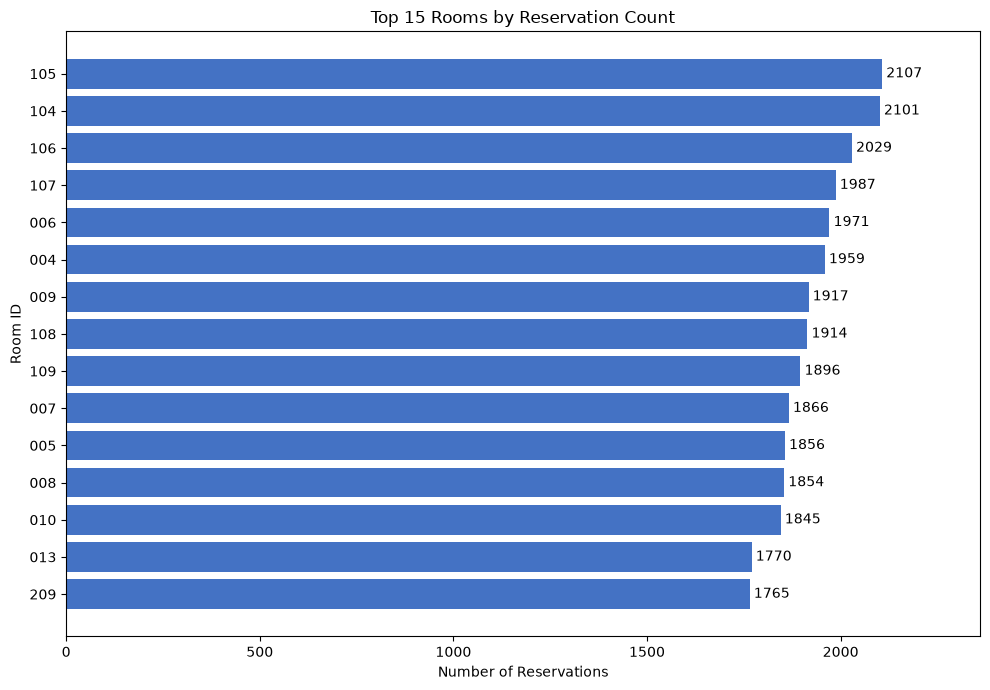

In [5]:
top_rooms = (
    reservations_by_room.head(15)
    .sort_values("reservation_count")
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    top_rooms["room_id"],
    top_rooms["reservation_count"],
    color="#4472C4"
)

plt.bar_label(bars, padding=3)
plt.title("Top 15 Rooms by Reservation Count")
plt.xlabel("Number of Reservations")
plt.ylabel("Room ID")
plt.xlim(0, top_rooms["reservation_count"].max() * 1.12)
plt.tight_layout()
plt.show()

## 3. Reservation Counts by Weekday

This metric shows how reservation demand varies across the week. Weekdays are arranged in chronological order rather than alphabetical order.

,weekday,reservation_count
0,Monday,8164
1,Tuesday,9198
2,Wednesday,9233
3,Thursday,8721
4,Friday,6739
5,Saturday,3780
6,Sunday,5484


PASS: Weekday reservation counts sum to 51,319.


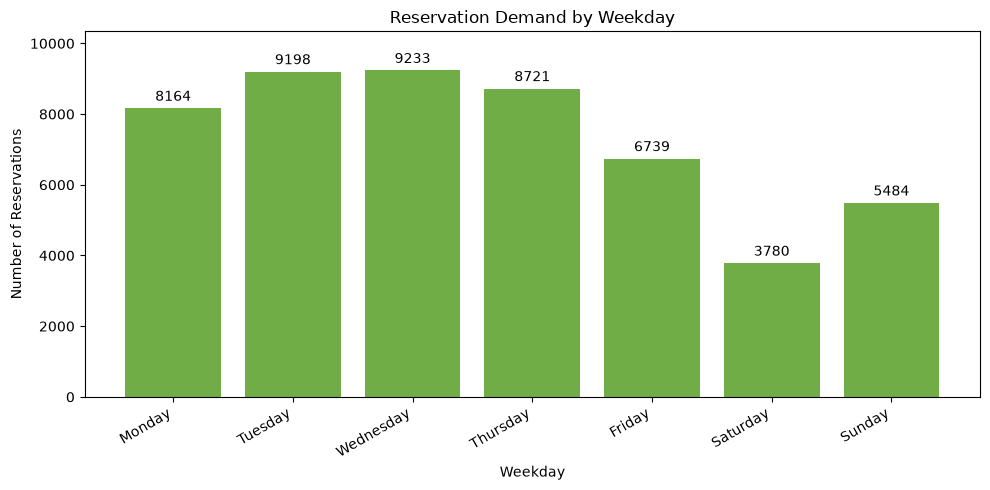

In [6]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

reservations_by_weekday = (
    df.groupby("weekday")
      .size()
      .reindex(weekday_order, fill_value=0)
      .reset_index(name="reservation_count")
)

weekday_total = int(
    reservations_by_weekday["reservation_count"].sum()
)

display(reservations_by_weekday)

assert weekday_total == 51319
print("PASS: Weekday reservation counts sum to 51,319.")

plt.figure(figsize=(10, 5))

bars = plt.bar(
    reservations_by_weekday["weekday"],
    reservations_by_weekday["reservation_count"],
    color="#70AD47"
)

plt.bar_label(bars, padding=3)
plt.title("Reservation Demand by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Reservations")
plt.xticks(rotation=30, ha="right")
plt.ylim(
    0,
    reservations_by_weekday["reservation_count"].max() * 1.12
)
plt.tight_layout()
plt.show()

### Finding

Wednesday recorded the highest reservation demand with 9,233 reservations, closely followed by Tuesday with 9,198. Saturday had the lowest demand with 3,780 reservations. This suggests that room demand is strongest during the middle of the working week.

## 4. Reservation Counts by Start Hour

This metric identifies the times of day when reservations most frequently begin. All 24 hours are included so that hours with no reservation starts remain visible.

,start_hour,reservation_count
0,0,301
1,1,57
2,2,4
3,3,3
4,4,4
5,5,1
6,6,13
7,7,870
8,8,1928
9,9,3358


PASS: Start-hour reservation counts sum to 51,319.


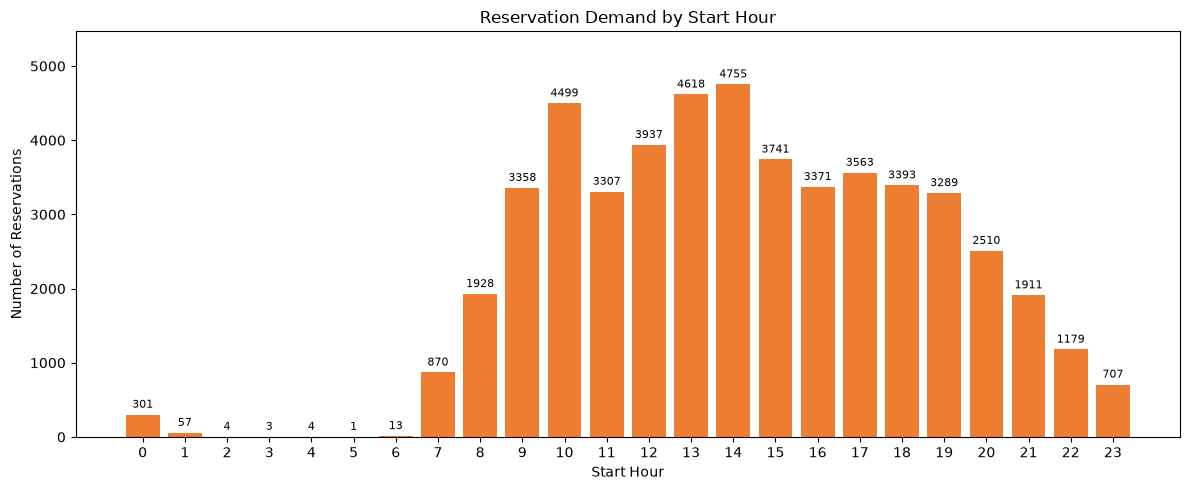

In [7]:
reservations_by_hour = (
    df.groupby("start_hour")
      .size()
      .reindex(range(24), fill_value=0)
      .reset_index(name="reservation_count")
)

hour_total = int(
    reservations_by_hour["reservation_count"].sum()
)

display(reservations_by_hour)

assert hour_total == 51319
print("PASS: Start-hour reservation counts sum to 51,319.")

plt.figure(figsize=(12, 5))

bars = plt.bar(
    reservations_by_hour["start_hour"],
    reservations_by_hour["reservation_count"],
    color="#ED7D31"
)

plt.bar_label(bars, padding=3, fontsize=8)
plt.title("Reservation Demand by Start Hour")
plt.xlabel("Start Hour")
plt.ylabel("Number of Reservations")
plt.xticks(range(24))
plt.ylim(
    0,
    reservations_by_hour["reservation_count"].max() * 1.15
)
plt.tight_layout()
plt.show()

### Finding

The busiest reservation start time was 14:00, with 4,755 reservations. This was followed by 13:00 with 4,618 reservations and 10:00 with 4,499 reservations. Demand was concentrated mainly during daytime and evening operating hours.

## 5. Reserved Hours by Room

Reserved hours measure the total amount of room time booked, rather than only the number of reservations. The first five records are manually checked before calculating totals for all rooms.

,room_id,start_time,end_time,duration_minutes
0,109,2024-01-06 14:30:00,2024-01-06 18:00:00,210
1,033,2024-01-06 14:27:45,2024-01-06 16:27:45,120
2,326,2024-01-06 15:22:29,2024-01-06 16:22:29,60
3,107,2024-01-06 15:37:48,2024-01-06 17:37:48,120
4,032,2024-01-06 15:54:41,2024-01-06 17:54:41,120


Manual sample total minutes: 630
Manual sample total hours: 10.5
PASS: First five reservations total 630 minutes or 10.5 hours.


,room_id,reserved_minutes,reserved_hours
0,104,197069,3284.48
1,105,194538,3242.30
2,106,192679,3211.32
3,107,192105,3201.75
4,108,186392,3106.53
5,005,185533,3092.22
6,006,185293,3088.22
7,032,182532,3042.20
8,008,179423,2990.38
9,007,178437,2973.95


PASS: Reserved-time totals match the full dataset.


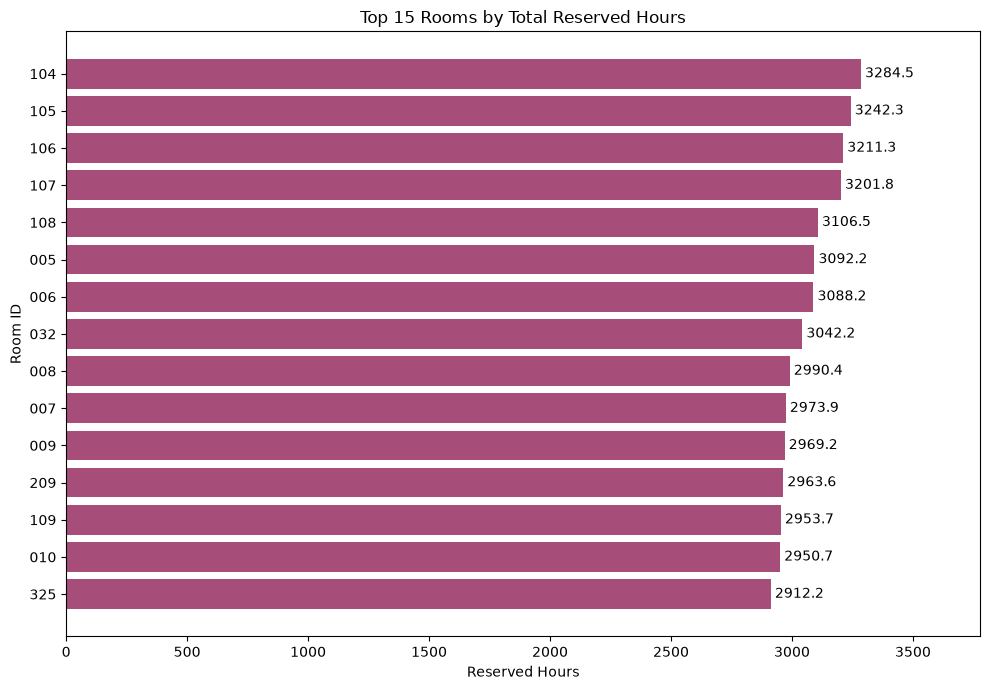

In [8]:
# Manual validation using the first five records
manual_sample = df.head(5)[
    ["room_id", "start_time", "end_time", "duration_minutes"]
].copy()

manual_sample_total_minutes = int(
    manual_sample["duration_minutes"].sum()
)

manual_sample_total_hours = (
    manual_sample_total_minutes / 60
)

display(manual_sample)

print("Manual sample total minutes:", manual_sample_total_minutes)
print("Manual sample total hours:", manual_sample_total_hours)

assert manual_sample_total_minutes == 630
assert manual_sample_total_hours == 10.5

print("PASS: First five reservations total 630 minutes or 10.5 hours.")

# Calculate reserved time for every room
reserved_hours_by_room = (
    df.groupby("room_id", as_index=False)["duration_minutes"]
      .sum()
      .rename(columns={"duration_minutes": "reserved_minutes"})
)

reserved_hours_by_room["reserved_hours"] = (
    reserved_hours_by_room["reserved_minutes"] / 60
).round(2)

reserved_hours_by_room = (
    reserved_hours_by_room
    .sort_values(
        by=["reserved_hours", "room_id"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

assert (
    reserved_hours_by_room["reserved_minutes"].sum()
    == df["duration_minutes"].sum()
)

display(reserved_hours_by_room.head(10))
print("PASS: Reserved-time totals match the full dataset.")

# Chart the 15 rooms with the most reserved hours
top_reserved_hours = (
    reserved_hours_by_room.head(15)
    .sort_values("reserved_hours")
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    top_reserved_hours["room_id"],
    top_reserved_hours["reserved_hours"],
    color="#A64D79"
)

plt.bar_label(bars, padding=3, fmt="%.1f")
plt.title("Top 15 Rooms by Total Reserved Hours")
plt.xlabel("Reserved Hours")
plt.ylabel("Room ID")
plt.xlim(
    0,
    top_reserved_hours["reserved_hours"].max() * 1.15
)
plt.tight_layout()
plt.show()

### Reserved-hours finding

Room 104 had the highest total reserved time at 3,284.5 hours, followed by room 105 at 3,242.3 hours and room 106 at 3,211.3 hours. These totals represent historical reservation demand, not necessarily actual room usage.

In [9]:
# Calculate overall reservation-duration metrics
average_duration_minutes = df["duration_minutes"].mean()
average_duration_hours = average_duration_minutes / 60
median_duration_minutes = df["duration_minutes"].median()
total_reserved_hours = df["duration_minutes"].sum() / 60

# Validate the average manually
manual_average = df["duration_minutes"].sum() / len(df)
assert abs(average_duration_minutes - manual_average) < 1e-9

duration_summary = pd.DataFrame({
    "metric": [
        "Average reservation duration (minutes)",
        "Average reservation duration (hours)",
        "Median reservation duration (minutes)",
        "Total reserved hours"
    ],
    "value": [
        round(average_duration_minutes, 2),
        round(average_duration_hours, 2),
        round(median_duration_minutes, 2),
        round(total_reserved_hours, 2)
    ]
})

display(duration_summary)

,metric,value
0,Average reservation duration (minutes),95.43
1,Average reservation duration (hours),1.59
2,Median reservation duration (minutes),90.00
3,Total reserved hours,81622.72


### Reservation-duration finding

Across all 51,319 reservations, the average reservation duration was 95.43 minutes, while the median was 90 minutes. The historical dataset contained 81,622.72 total reserved hours.

## 6. Data Quality Investigations

### Overlapping Reservations

In [10]:
# Sort reservations chronologically within each room
overlap_check = df.sort_values(
    ["room_id", "start_time", "end_time"]
).copy()

# Compare each reservation with the preceding reservation in the same room
room_groups = overlap_check.groupby("room_id")

overlap_check["previous_start_time"] = (
    room_groups["start_time"].shift(1)
)

overlap_check["previous_end_time"] = (
    room_groups["end_time"].shift(1)
)

# An overlap occurs when the next reservation starts
# before the preceding reservation ends
overlapping_records = overlap_check[
    overlap_check["start_time"] < overlap_check["previous_end_time"]
].copy()

print("Number of overlapping cases:", len(overlapping_records))

display(
    overlapping_records[
        [
            "room_id",
            "previous_start_time",
            "previous_end_time",
            "start_time",
            "end_time"
        ]
    ]
)

assert len(overlapping_records) == 2

Number of overlapping cases: 2


,room_id,previous_start_time,previous_end_time,start_time,end_time
26184,234,2024-05-29 14:00:00,2024-05-29 15:00:00,2024-05-29 14:15:00,2024-05-29 15:15:00
27564,234,2024-06-05 14:00:00,2024-06-05 15:00:00,2024-06-05 14:15:00,2024-06-05 15:15:00


#### Overlap investigation finding

Two overlap cases were identified, both involving Room 234:

- On 29 May 2024, the 14:00–15:00 reservation overlaps with the 14:15–15:15 reservation.
- On 5 June 2024, the 14:00–15:00 reservation overlaps with the 14:15–15:15 reservation.

Each case contains a 45-minute overlap. The records are retained because they are part of the source dataset, but they are documented as data-quality anomalies. Therefore, the main analytics still include all 51,319 records.

### Dates Without Reservation Starts

In [11]:
# Determine the dataset's covered date interval
coverage_start = df["start_time"].dt.normalize().min()
coverage_end = df["start_time"].dt.normalize().max()

# Create every calendar date within the covered interval
all_dates = pd.date_range(
    start=coverage_start,
    end=coverage_end,
    freq="D"
)

# Find dates that appear in the reservation records
dates_with_reservations = pd.DatetimeIndex(
    df["start_time"].dt.normalize().unique()
)

# Identify dates without any reservation starts
dates_without_reservations = all_dates.difference(
    dates_with_reservations
)

missing_dates_table = pd.DataFrame({
    "date": dates_without_reservations,
    "weekday": dates_without_reservations.day_name()
})

print("Dataset coverage:", coverage_start.date(), "to", coverage_end.date())
print("Number of dates without reservation starts:",
      len(dates_without_reservations))

display(missing_dates_table)

assert len(dates_without_reservations) == 9

Dataset coverage: 2024-01-06 to 2024-12-31
Number of dates without reservation starts: 9


,date,weekday
0,2024-09-07,Saturday
1,2024-09-08,Sunday
2,2024-09-14,Saturday
3,2024-09-15,Sunday
4,2024-12-14,Saturday
5,2024-12-21,Saturday
6,2024-12-22,Sunday
7,2024-12-28,Saturday
8,2024-12-29,Sunday


#### Missing-date investigation finding

The dataset covers reservation starts from 6 January to 31 December 2024. Nine dates within this interval contain no reservation starts, and all nine are Saturdays or Sundays.

It cannot be confirmed whether these dates represent genuine zero demand, library closures or missing source data. Therefore, no synthetic reservation records were added, and the dates are documented as a source-data limitation.

### Source Timezone

In [12]:
# Check whether the parsed timestamps contain timezone information
start_timezone = df["start_time"].dt.tz
end_timezone = df["end_time"].dt.tz

print("Start-time timezone:", start_timezone)
print("End-time timezone:", end_timezone)

assert start_timezone is None
assert end_timezone is None

Start-time timezone: None
End-time timezone: None


#### Timezone investigation finding

The source dataset does not specify its timezone, and its timestamps do not contain UTC offsets or timezone information. Therefore, the timestamps are treated as timezone-naive source-local times. No conversion to UTC or Singapore Time was performed because doing so would require an unsupported assumption about the source location.

## 7. Export Dashboard Metrics

The following files contain verified descriptive metrics derived from all 51,319 historical reservation records. They are intended for use by the Roomly analytics dashboard.

In [13]:
from pathlib import Path
import json

# Always write dashboard files to analytics/output
output_directory = project_root / "analytics" / "output"
output_directory.mkdir(parents=True, exist_ok=True)

# 1. Metrics by room
room_metrics = (
    df.groupby("room_id", as_index=False)
      .agg(
          reservation_count=("room_id", "size"),
          reserved_minutes=("duration_minutes", "sum")
      )
)

room_metrics["reserved_hours"] = (
    room_metrics["reserved_minutes"] / 60
).round(2)

room_metrics = room_metrics.drop(columns="reserved_minutes")

# 2. Metrics by weekday
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_metrics = (
    df["weekday"]
    .value_counts()
    .reindex(weekday_order, fill_value=0)
    .rename_axis("weekday")
    .reset_index(name="reservation_count")
)

# 3. Metrics by start hour
hour_metrics = (
    df["start_hour"]
    .value_counts()
    .reindex(range(24), fill_value=0)
    .sort_index()
    .rename_axis("start_hour")
    .reset_index(name="reservation_count")
)

# Validate exported reservation totals
assert room_metrics["reservation_count"].sum() == 51319
assert weekday_metrics["reservation_count"].sum() == 51319
assert hour_metrics["reservation_count"].sum() == 51319

# Export CSV files
room_metrics.to_csv(
    output_directory / "reservations_by_room.csv",
    index=False
)

weekday_metrics.to_csv(
    output_directory / "reservations_by_weekday.csv",
    index=False
)

hour_metrics.to_csv(
    output_directory / "reservations_by_start_hour.csv",
    index=False
)

# Export overall summary as JSON
summary_metrics = {
    "record_count": int(len(df)),
    "room_count": int(df["room_id"].nunique()),
    "average_duration_minutes": round(
        float(df["duration_minutes"].mean()), 2
    ),
    "median_duration_minutes": round(
        float(df["duration_minutes"].median()), 2
    ),
    "total_reserved_hours": round(
        float(df["duration_minutes"].sum() / 60), 2
    ),
    "coverage_start": str(df["start_time"].min().date()),
    "coverage_end": str(df["start_time"].max().date()),
    "overlap_cases": int(len(overlapping_records)),
    "dates_without_reservation_starts": int(
        len(dates_without_reservations)
    ),
    "source_timezone": None
}

with open(
    output_directory / "summary_metrics.json",
    "w",
    encoding="utf-8"
) as json_file:
    json.dump(summary_metrics, json_file, indent=2)

print("Analytics files exported successfully:")
for file_path in sorted(output_directory.iterdir()):
    print("-", file_path)

Analytics files exported successfully:
- C:\Users\yuche\Documents\GitHub\INF2006_ClassroomBooking\analytics\output\reservations_by_room.csv
- C:\Users\yuche\Documents\GitHub\INF2006_ClassroomBooking\analytics\output\reservations_by_start_hour.csv
- C:\Users\yuche\Documents\GitHub\INF2006_ClassroomBooking\analytics\output\reservations_by_weekday.csv
- C:\Users\yuche\Documents\GitHub\INF2006_ClassroomBooking\analytics\output\summary_metrics.json
